# **CHAPTER 4 Training Models**


The Normal Equation:

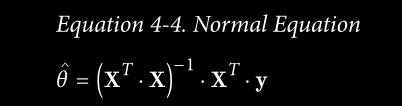

In [1]:
import numpy as np
import matplotlib.pyplot as plt
 
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

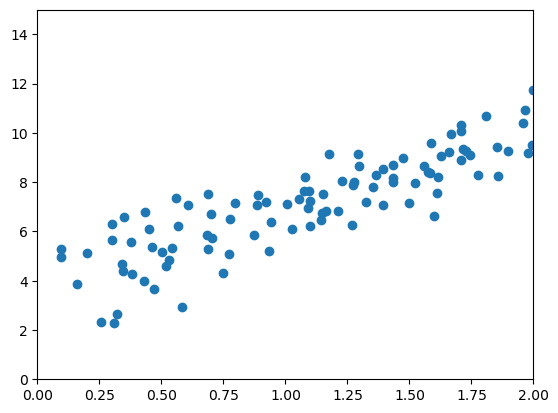

In [2]:
plt.scatter(X, y)
plt.axis([0, 2, 0, 15])
plt.show()

In [3]:
len(X)

100

In [4]:
X_b = np.c_[np.ones((100, 1)), X]
X_b.T

array([[1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.  

In [5]:
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

In [6]:
theta_best

array([[3.71410492],
       [3.14761104]])

In [7]:
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2,1)), X_new]

print(X_new)
print(X_new_b)

[[0]
 [2]]
[[1. 0.]
 [1. 2.]]


In [8]:
y_pred = X_new_b.dot(theta_best)
y_pred

array([[ 3.71410492],
       [10.00932701]])

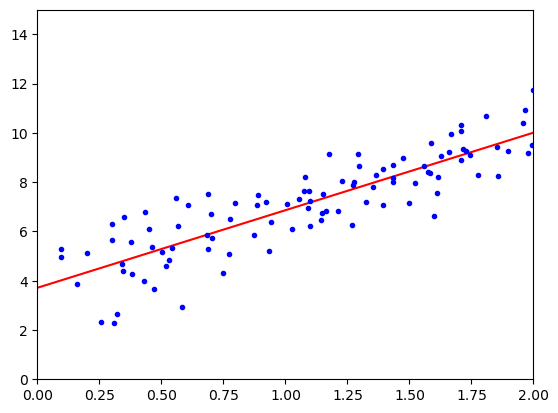

In [9]:
plt.plot(X_new, y_pred, "r-")
plt.plot(X, y, 'b.' )
plt.axis([0, 2, 0, 15])
plt.show()

using sklearn library

In [27]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X, y)

print(lr.intercept_, lr.coef_)
print(lr.predict(X_new))
 

[3.71410492] [[3.14761104]]
[[ 3.71410492]
 [10.00932701]]


**Computational Complexity**

(X^T . X) . inv(X) -> n^3 for Normal Equation

# **Gradient Descent**

In [28]:
lr = 0.1 
n_iterations = 1000
m = 100

theta =np.random.randn(2,1)

for iteration in range(n_iterations):
    gradient_descent = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - lr * gradient_descent

print(theta)

[[3.71410492]
 [3.14761104]]


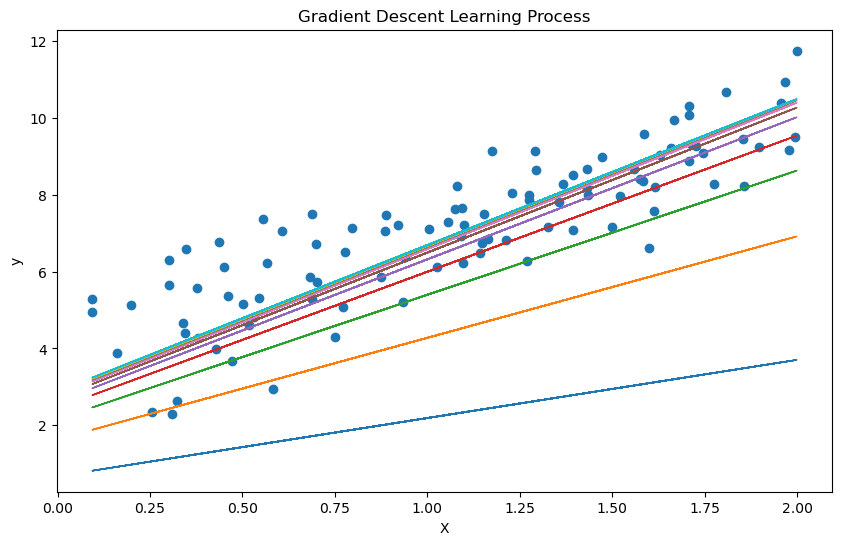

In [41]:
theta = np.random.randn(2,1)

theta_history_batch = []

learning_rate = 0.1
n_iterations = 200
m = len(X_b)

plt.figure(figsize=(10,6))

plt.scatter(X, y)

for iteration in range(n_iterations):

    y_predict = X_b.dot(theta)
    if iteration < 10:
        plt.plot(X, y_predict, linewidth=1)
        
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - learning_rate * gradients
    
    theta_history_batch.append(theta.copy()) 
    
theta_history_batch = np.array(theta_history_batch).squeeze()


plt.xlabel("X")
plt.ylabel("y")
plt.title("Gradient Descent Learning Process")
plt.show()

In [42]:
theta

array([[3.70695806],
       [3.15342536]])

# **Stochastic Gradient Descent**

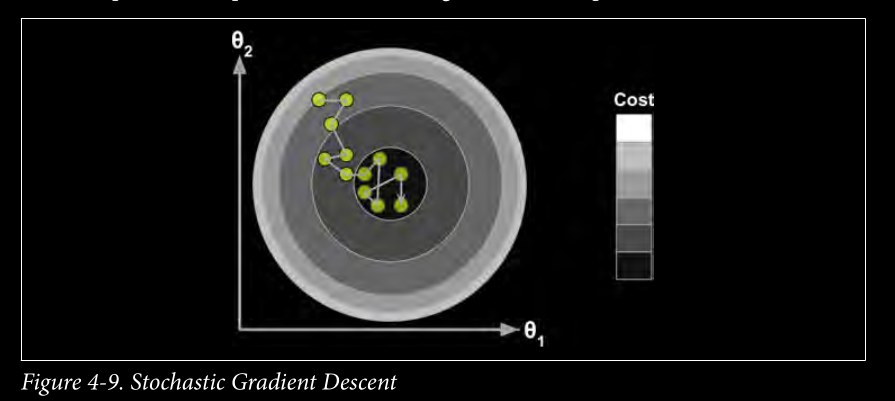

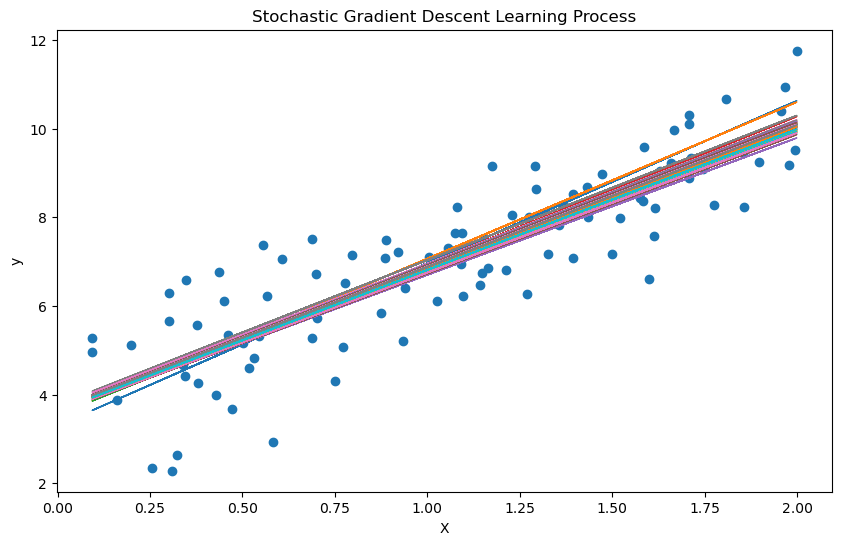

In [43]:
n_epochs = 50
t0, t1 = 5, 50 # learning schedule hyperparameters
theta_history_SGD = []

def learning_schedule(t):
    return t0 / (t + t1)

theta = np.random.randn(2,1)

plt.figure(figsize=(10,6))
plt.scatter(X, y)

for epoch in range(n_epochs):
    for i in range(m):
        random_index = np.random.randint(m)
        
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
                
        gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
        
        eta = learning_schedule(epoch * m + i)
        
        theta = theta - eta * gradients

        theta_history_SGD.append(theta.copy())
    y_predict = X_b.dot(theta)
    plt.plot(X, y_predict, linewidth=1)

theta_history_SGD = np.array(theta_history_SGD).squeeze()

plt.xlabel("X")
plt.ylabel("y")
plt.title("Stochastic Gradient Descent Learning Process")
plt.show()


In [44]:
theta

array([[3.63556069],
       [3.17603092]])

In [45]:
from sklearn.linear_model import SGDRegressor
sgd_reg = SGDRegressor(max_iter=50, penalty=None, eta0=0.1)
sgd_reg.fit(X, y.ravel())

SGDRegressor(eta0=0.1, max_iter=50, penalty=None)

In [46]:
sgd_reg.intercept_, sgd_reg.coef_

(array([3.68460911]), array([3.1315253]))

# **Mini-batch Gradient Descent**

12


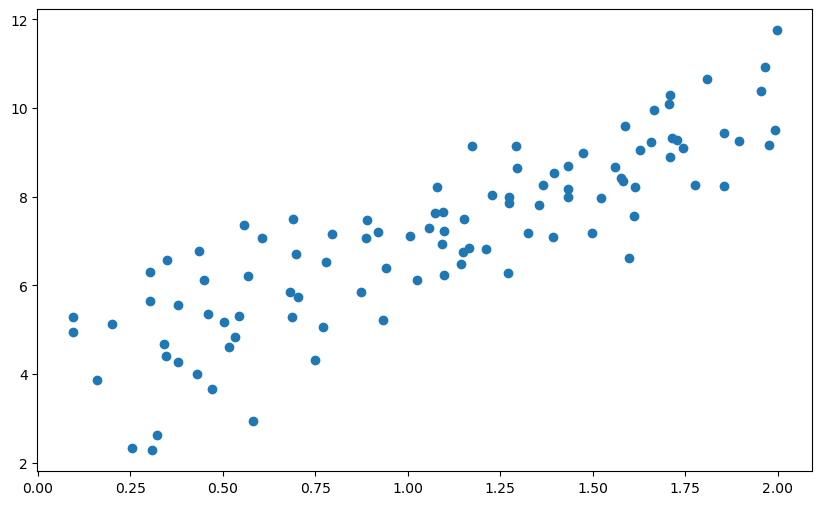

In [47]:
batch_size = 8
n_iterations_per_epoch = m // batch_size
print(n_iterations_per_epoch)

plt.figure(figsize=(10,6))
plt.scatter(X, y)

for epoch in range(n_epochs):
    indices = np.random.permutation(m)
    for j in range(0, m, batch_size):
        batch_idx = indices[j:j+batch_size]
        xi = X_b[batch_idx]
        yi = y[batch_idx]
        gradients = 2/len(batch_idx) * xi.T.dot(xi.dot(theta) - yi)
        eta = learning_schedule(epoch * n_iterations_per_epoch + j//batch_size)
        theta -= eta * gradients
        


**Divergence**

This is the dangerous one.
It happens when learning rate is TOO LARGE.

Example: η=10

```
What Happens?

Updates overshoot the minimum.

Instead of approaching minimum:

jump left
jump right
jump farther away

until values explode.
```


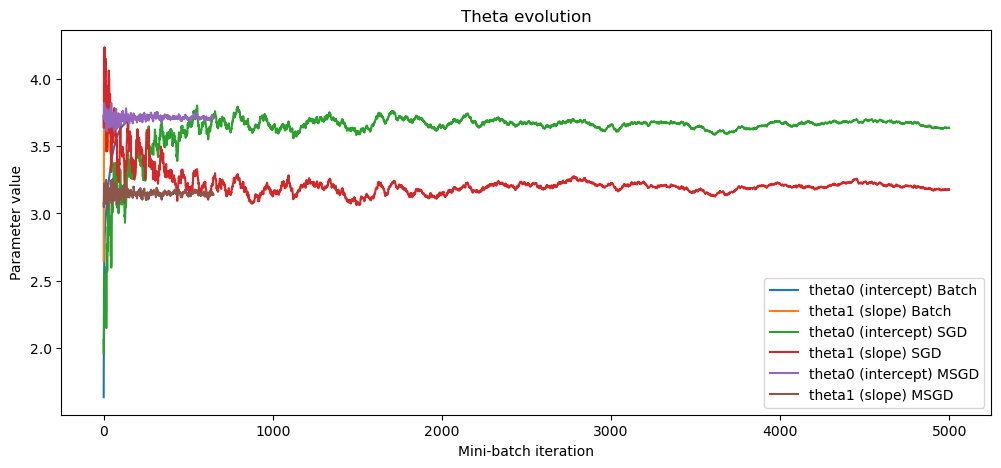

In [ ]:
theta_history_Mini_SGD = []

for epoch in range(n_epochs):
    indices = np.random.permutation(m)
    for j in range(0, m, batch_size):
        batch_idx = indices[j:j+batch_size]
        xi = X_b[batch_idx]
        yi = y[batch_idx]
        gradients = 2/len(batch_idx) * xi.T.dot(xi.dot(theta) - yi)
        eta = learning_schedule(epoch * n_iterations_per_epoch + j//batch_size)
        theta -= eta * gradients
        
        theta_history_Mini_SGD.append(theta.copy())

# After training, plot theta0 and theta1 over iterations
theta_history_Mini_SGD = np.array(theta_history_Mini_SGD).squeeze()  # shape (n_updates, 2)

plt.figure(figsize=(12,5))
plt.plot(theta_history_Mini_SGD[:,0], label='theta0 (intercept)')
plt.plot(theta_history_Mini_SGD[:,1], label='theta1 (slope)')
plt.xlabel('Mini-batch iteration')
plt.ylabel('Parameter value')
plt.legend()
plt.title('Theta evolution')
plt.show()

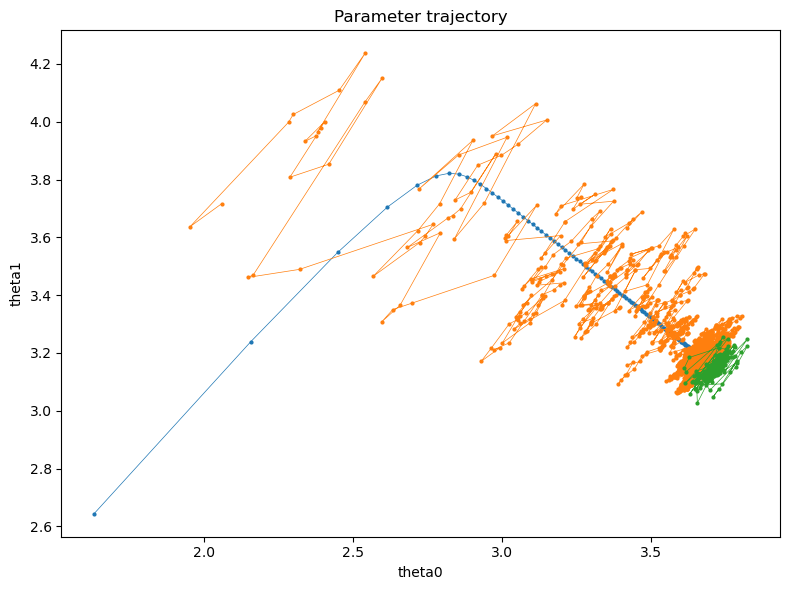

In [ ]:
# plt.figure(figsize=(8,6))
# plt.plot(theta_history_batch[:,0],theta_history_batch[:,1],  'o-', markersize=2, linewidth=0.5, label='Batch')
# plt.plot(theta_history_SGD[:,0],theta_history_SGD[:,1], 'o-', markersize=2, linewidth=0.5, label='SGD')
# plt.plot(theta_history_Mini_SGD[:,0], theta_history_Mini_SGD[:,1], 'o-', markersize=2, linewidth=0.5, label='MSGD')
# plt.xlabel('theta0')
# plt.ylabel('theta1')
# plt.title('Parameter trajectory')
# plt.tight_layout()
# plt.show()

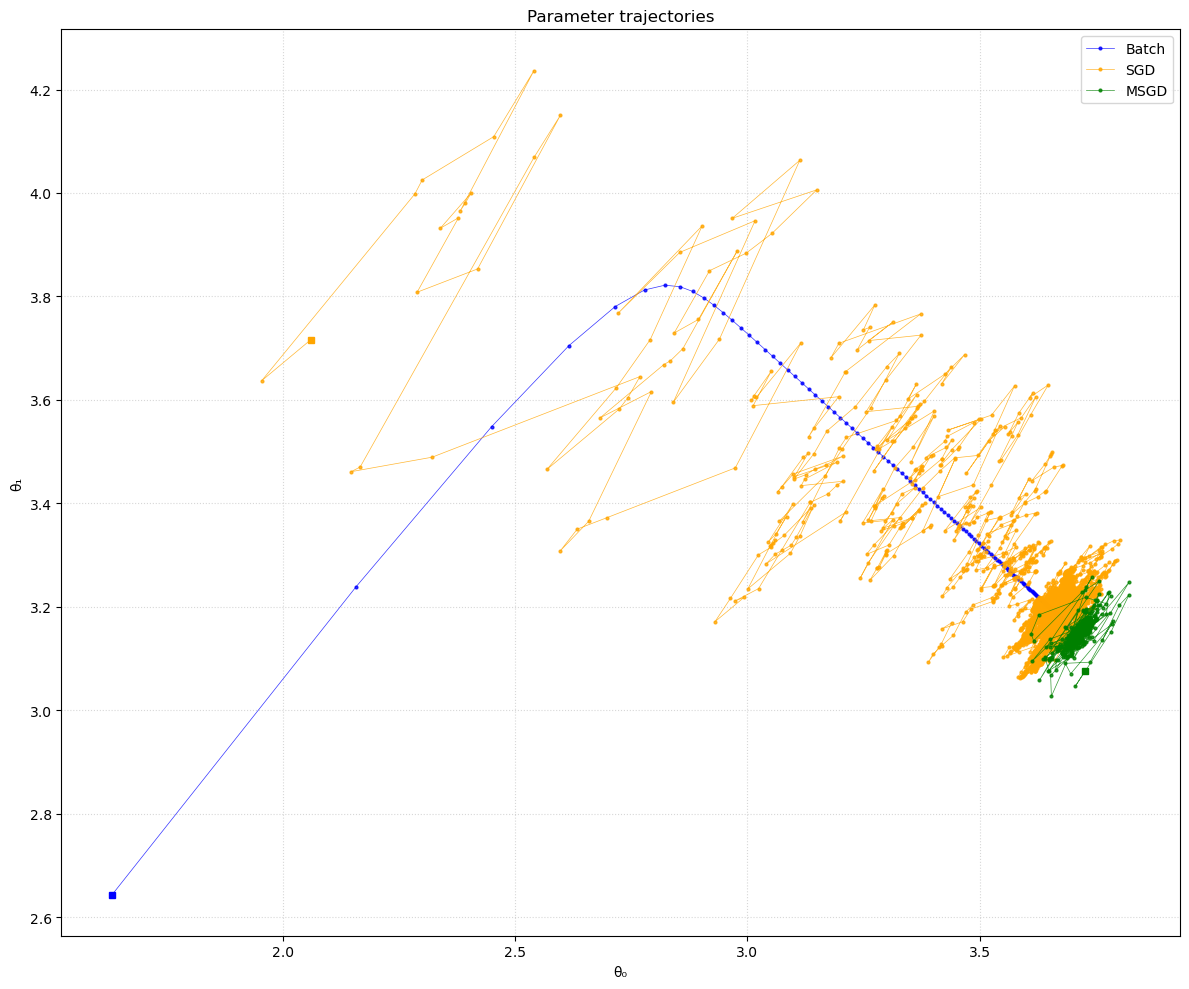

In [52]:
plt.figure(figsize=(12,10))

for hist, label, color in zip(
    [theta_history_batch, theta_history_SGD, theta_history_Mini_SGD],
    ['Batch', 'SGD', 'MSGD'],
    ['blue', 'orange', 'green']
):
    if hist is not None and len(hist) > 0:
        plt.plot(hist[:,0], hist[:,1], 'o-', markersize=2, linewidth=0.5,
                 color=color, label=label, alpha=0.8)
        # mark starting point
        plt.plot(hist[0,0], hist[0,1], 's', color=color, markersize=4)
        # mark end point
        plt.plot(hist[-1,0], hist[-1,1], '*', color=color, markersize=6)

plt.xlabel('θ₀')
plt.ylabel('θ₁')
plt.title('Parameter trajectories')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

## **Comparison of algorithms for Linear Regression**
| Algorithm | Large \(m\) | Out‑of‑core support | Large \(n\) | Hyperparams | Scaling required | Scikit‑Learn |
|-----------|-------------|----------------------|-------------|-------------|------------------|---------------|
| **Normal Equation** | Fast* (if \(n\) small) | No | Slow (\(O(n^3)\)) | 0 | No | `LinearRegression` |
| **Batch GD** | Slow (one epoch = O(m n)) | No | Fast (iterations scale with n) | ≥2 (lr, epochs) | Yes | n/a (no direct batch GD; use `SGDRegressor` with batch size = m via `partial_fit` manually) |
| **Stochastic GD** | Fast (per‑sample updates) | Yes | Fast | ≥2 (lr, epochs, …) | Yes | `SGDRegressor` |
| **Mini‑batch GD** | Fast (per‑batch updates) | Yes | Fast | ≥3 (lr, batch size, epochs) | Yes | `SGDRegressor` (set `batch_size`; default mini‑batch) |


# **Polynomial Regression**

In [108]:
m = 300
X = 5 * np.random.rand(m, 1) - 3
# y = ax2 + bx + c.
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)

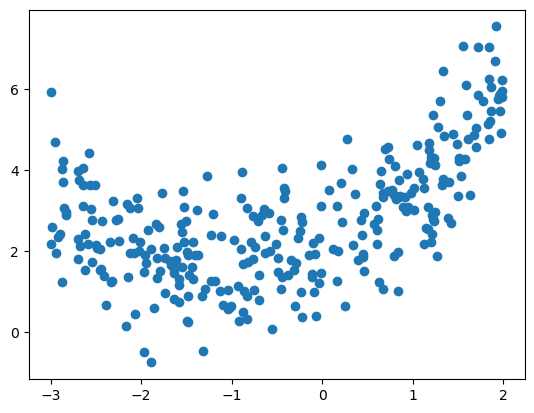

In [109]:
plt.scatter(X, y)
plt.show()

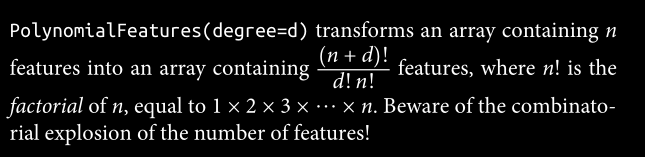

In [115]:
from sklearn.preprocessing import PolynomialFeatures
plyf = PolynomialFeatures(degree=15, include_bias=False)
X_poly = plyf.fit_transform(X)
X[0]

array([-1.52370151])

In [116]:
X_poly[0]

array([  -1.52370151,    2.3216663 ,   -3.53752645,    5.3901344 ,
         -8.21295593,   12.51409336,  -19.06774298,   29.0535488 ,
        -44.26893623,   67.45264507, -102.77769726,  156.6025327 ,
       -238.61551584,  363.57882223, -553.98560111])

In [117]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_poly, y)
print(lr.intercept_, lr.coef_)

[2.08922656] [[ 4.17143054e-01  2.02665594e+00  2.04098747e+00 -3.58004838e+00
  -3.56170139e+00  2.49410014e+00  2.89105224e+00 -5.01575020e-01
  -1.15495843e+00 -1.29705103e-01  2.12942055e-01  6.65249046e-02
  -1.06664154e-02 -7.33861031e-03 -8.81479684e-04]]


In [118]:
X_smooth = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
X_smooth_poly = plyf.transform(X_smooth)
y_smooth = lr.predict(X_smooth_poly)

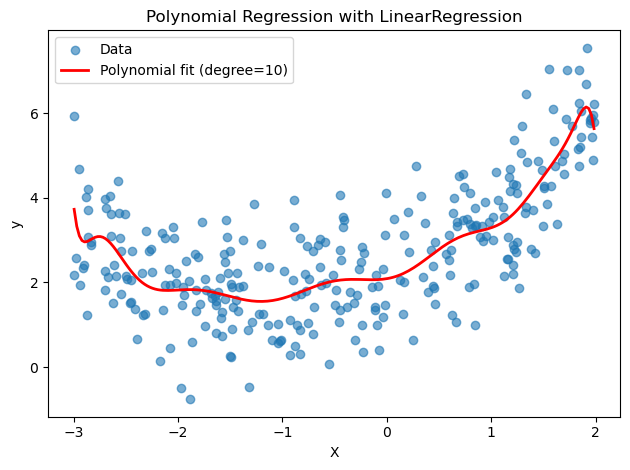

In [119]:
plt.scatter(X, y, alpha=0.6, label='Data')
plt.plot(X_smooth, y_smooth, 'r-', linewidth=2, label='Polynomial fit (degree=10)')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Polynomial Regression with LinearRegression')
plt.legend()
plt.tight_layout()
plt.show()